# Olist Ecommerce Sales Analysis – Python

## 1. Project Overview
**Description:**  
This Python stage of the project builds on the SQL analysis. We explore revenue trends, customer behavior, seller performance, product insights, delivery efficiency, and regional revenue patterns using **Pandas**, **Matplotlib**, and **Seaborn**. The goal is to practice Python analytics while generating actionable insights.

## 2. Data Loading & Inspection
**Description:**  
Load data from the database using `psycopg2` or `SQLAlchemy`. Inspect dataframes, check column types, missing values, duplicates, and basic statistics.

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, inspect
from matplotlib.ticker import FuncFormatter, MultipleLocator, ScalarFormatter

In [5]:
username = "root"
password = "abelytics"
database = "olist_ecommerce_db"
host = "127.0.0.1:3306"

In [6]:
engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}/{database}")
connection = engine.connect()
print("Connected successfully!")

Connected successfully!


###

## 🧠 1. Get Inspector (Core Tool)
👉 This `inspector` is your **database explorer**

### 1. Get all tables

In [7]:
inspector = inspect(engine)
tables = inspector.get_table_names()
print(tables)

['customers', 'geolocation', 'order_items', 'order_payments', 'order_reviews', 'orders', 'product_category_name_translation', 'products', 'sellers']


### 2. Get all views

In [222]:
views = inspector.get_view_names()
print(views)

['vw_customer_summary', 'vw_revenue_by_state']


### 3.Get Columns for Each Table

In [224]:
# for table in inspector.get_table_names():
#     print(f"\nTable: {table}")
    
#     columns = inspector.get_columns(table)
    
#     for col in columns:
#         print(f"  {col['name']} ({col['type']})")

### 4.Get Primary Keys

In [225]:
# for table in inspector.get_table_names():
#     pk = inspector.get_pk_constraint(table)
#     print(f"{table} PK:", pk["constrained_columns"])

### 5.Get Foreign Keys (Relationships 🔥)

In [227]:
# for table in inspector.get_table_names():
#     fks = inspector.get_foreign_keys(table)
    
#     print(f"\n{table} Foreign Keys:")
#     for fk in fks:
#         print(f"  {fk['constrained_columns']} → {fk['referred_table']}.{fk['referred_columns']}")

### 6. Get Indexes

In [228]:
# for table in inspector.get_table_names():
#     indexes = inspector.get_indexes(table)
#     print(f"{table} Indexes:", indexes)

### 7. Get Table Schema (Database Structure)

In [213]:
schemas = inspector.get_schema_names()
print(schemas)

['amazon_product_reviews', 'globomart', 'information_schema', 'kms_inventory', 'md_water_services', 'mysql', 'olist_ecommerce_db', 'performance_schema', 'sakila', 'salesdb', 'sys']


### 8. Get View Definition (SQL Behind View)

In [230]:
# for view in inspector.get_view_names():
#     definition = inspector.get_view_definition(view)
#     print(f"\nView: {view}")
#     print(definition)

### 8. Get Indexes

In [231]:
# for table in inspector.get_table_names():
#     indexes = inspector.get_indexes(table)
#     print(f"{table} Indexes:", indexes)

### 10. FULL DATABASE OVERVIEW SCRIPT

In [232]:
# print("SCHEMAS:", inspector.get_schema_names())

# print("\nTABLES:", inspector.get_table_names())

# print("\nVIEWS:", inspector.get_view_names())

# for table in inspector.get_table_names():
#     print(f"\n========== {table} ==========")
    
#     # Columns
#     for col in inspector.get_columns(table):
#         print(f"{col['name']} - {col['type']}")
    
#     # Primary Key
#     pk = inspector.get_pk_constraint(table)
#     print("PK:", pk["constrained_columns"])
    
#     # Foreign Keys
#     for fk in inspector.get_foreign_keys(table):
#         print("FK:", fk["constrained_columns"], "→", fk["referred_table"])

# 🧠 SQL EQUIVALENT (Very Important for You)

| What you want | SQL                          |
| ------------- | ---------------------------- |
| Tables        | `SHOW TABLES`                |
| Views         | `SHOW VIEWS`                 |
| Columns       | `DESCRIBE table`             |
| Relationships | `INFORMATION_SCHEMA`         |
| Metadata      | `INFORMATION_SCHEMA.COLUMNS` |

---

# 🔥 BONUS: Using SQL (Universal Method)

If SQLAlchemy fails, use:

```python
import pandas as pd

pd.read_sql("""
SELECT table_name, column_name, data_type
FROM information_schema.columns
""", engine)
```

###

In [44]:
tables = [
    "customers",
    "sellers",
    "products",
    "orders",
    "order_items",
    "order_payments",
    "order_reviews",
    "geolocation",
    "product_category_name_translation"
    ]

In [9]:
db = {}

for table in tables:
    print(f"Loading {table}...")
    db[table] = pd.read_sql(f"SELECT * FROM {table}", engine)
    # print(db[table].info())
    # print(db[table].head(3))
    # print("\n")
    # print("---------------------------------------------------------------")
    # print("\n")

Loading customers...
Loading sellers...
Loading products...
Loading orders...
Loading order_items...
Loading order_payments...
Loading order_reviews...
Loading geolocation...
Loading product_category_name_translation...


In [10]:
customers = db["customers"]
products = db["products"]
orders = db["orders"]
order_items = db["order_items"]
order_reviews = db["order_reviews"]
order_payments = db["order_payments"]
sellers = db["sellers"]
geolocation = db["geolocation"]
pcnt = db["product_category_name_translation"]

### Null Check

In [11]:
# for table in tables:
#     print("==================================")
#     print(f"========={table.upper()}=========")
#     print("==================================")
#     print(db[table].isnull().sum())
#     print("\n")

### Duplicate Check

In [12]:
# for table in tables:
#     print("==================================")
#     print(f"========={table.upper()}=========")
#     print("==================================")
#     print(db[table].duplicated().sum())
#     print("\n")

In [13]:
# for table in tables:
#     print("==================================")
#     print(f"========={table.upper()}=========")
#     print("==================================")
#     print(db[table].dtypes)
#     print("\n")

### Delivered Orders

In [14]:
delivered_orders = orders[orders["order_status"] == "delivered"]
delivered_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17


### Merged Orders

In [15]:
merged_orders = pd.merge(
    delivered_orders,
    order_items,
    on="order_id",
    how="inner")

merged_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [16]:
merged_orders.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
order_item_id                             int64
product_id                               object
seller_id                                object
shipping_limit_date              datetime64[ns]
price                                   float64
freight_value                           float64
dtype: object

##
## 3. Monthly Revenue Trend
**Description:**  
Analyze revenue over months and years. Preprocessing includes creating `year`, `month`, `month_name`, `day`, `day_name`, and `hour` from delivery timestamp. Sorting months chronologically ensures correct visualization.

**Output Placeholder:**  
*(Paste bar chart of monthly revenue here)*

### Findings, Interpretation & Recommendations
*(Interpret peaks, dips, seasonality, trends, and suggest actionable insights.)*


### Total Revenue

In [17]:
total_revenue = merged_orders["price"].sum().round()
total_revenue

13221498.0

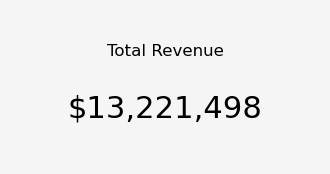

In [18]:
fig, ax = plt.subplots(figsize=(4,2))
fig.patch.set_facecolor('#f5f5f5')

ax.text(0.5, 0.7, "Total Revenue", fontsize=12, ha='center')
ax.text(0.5, 0.3, f"${total_revenue:,.0f}", fontsize=22, ha='center')

ax.axis("off")
plt.show()

### Extract Date Parts

In [19]:
merged_orders["year"] = merged_orders["order_delivered_customer_date"].dt.year
merged_orders["month"] = merged_orders["order_delivered_customer_date"].dt.month
merged_orders["month_name"] = merged_orders["order_delivered_customer_date"].dt.month_name()
merged_orders["day"] = merged_orders["order_delivered_customer_date"].dt.day
merged_orders["day_name"] = merged_orders["order_delivered_customer_date"].dt.day_name()
merged_orders["hour"] = merged_orders["order_delivered_customer_date"].dt.hour

merged_orders["year"] = merged_orders["year"].astype("Int64")
merged_orders["month"] = merged_orders["month"].astype("Int64")

In [20]:
merged_orders.loc[:, ["year", "month_name", "day_name"]]

,year,month_name,day_name
0,2017,September,Wednesday
1,2017,May,Friday
2,2018,January,Monday
3,2018,August,Tuesday
4,2017,March,Wednesday
...,...,...,...
110192,2018,May,Thursday
110193,2018,July,Monday
110194,2017,October,Saturday
110195,2017,August,Wednesday


###

### Monthly Revenue

In [21]:
monthly_revenue = (
    merged_orders
    .groupby(["year", "month", "month_name"])["price"]
    .sum()
    .round()
    .reset_index()
    .sort_values(["year", "month"])
)

monthly_revenue

,year,month,month_name,price
0,2016,10,October,29874.0
1,2016,11,November,9838.0
2,2016,12,December,759.0
3,2017,1,January,33599.0
4,2017,2,February,198909.0
5,2017,3,March,335886.0
6,2017,4,April,268687.0
7,2017,5,May,520141.0
8,2017,6,June,430780.0
9,2017,7,July,455001.0


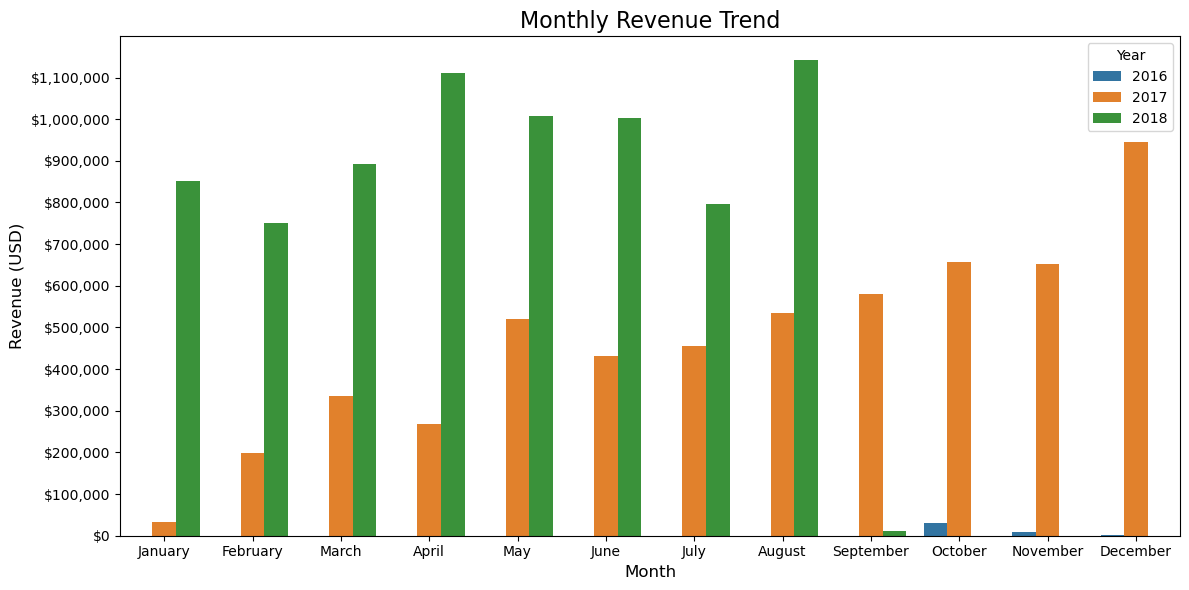

In [22]:
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

fig, ax = plt.subplots(figsize=(12, 6))

# Plot
sns.barplot(
    x="month_name",
    y="price",
    hue="year",
    data=monthly_revenue,
    order=month_order,
    ax=ax  # Attach plot to axes
)

# Set y-axis ticks every 1000 (locator)
ax.yaxis.set_major_locator(MultipleLocator(100000))

# Format y-axis labels as currency with thousands separator (formatter)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))

ax.set_title("Monthly Revenue Trend", fontsize=16)
ax.set_xlabel("Month", fontsize=12)
ax.set_ylabel("Revenue (USD)", fontsize=12)
# ax.ticklabel_format(style='plain', axis='y')  # prevent scientific notation
ax.legend(title="Year")

plt.tight_layout()

plt.show()

###

### Total Customer

In [23]:
total_customers  = customers["customer_unique_id"].nunique()

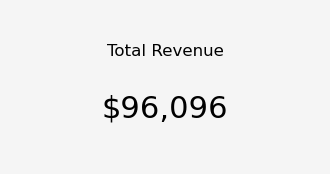

In [24]:
fig, ax = plt.subplots(figsize=(4,2))
fig.patch.set_facecolor('#f5f5f5')

ax.text(0.5, 0.7, "Total Revenue", fontsize=12, ha='center')
ax.text(0.5, 0.3, f"${total_customers:,.0f}", fontsize=22, ha='center')

ax.axis("off")
plt.show()

###

### Customer status and revenue summary

In [25]:
# merge customers with merged orders
customer_orders = merged_orders.merge(customers, on="customer_id")
# customer_orders.info()

In [26]:
# Determine customer status

customer_summary = (
    customer_orders
    .groupby("customer_unique_id")
    .agg(
        total_orders=("order_id", "count"),
        total_revenue=("price", "sum")
    )
    .reset_index()
)

# Add 'One Time' or 'Repeat' label
customer_summary["customer_status"] = customer_summary["total_orders"].apply(
    lambda x: "One Time" if x == 1 else "Repeat"
)

# Summarize by customer status
customer_status_summary = (
    customer_summary
    .groupby("customer_status")
    .agg(
        total_orders=("total_orders", "sum"),
        total_revenue=("total_revenue", "sum")
    )
    .reset_index()
)

# Calculate revenue percentage
customer_status_summary["revenue_percentage"] = (
    customer_status_summary["total_revenue"] / customer_status_summary["total_revenue"].sum() * 100
).round(2)

customer_status_summary

,customer_status,total_orders,total_revenue,revenue_percentage
0,One Time,81748,10698374.21,80.92
1,Repeat,28449,2523123.90,19.08


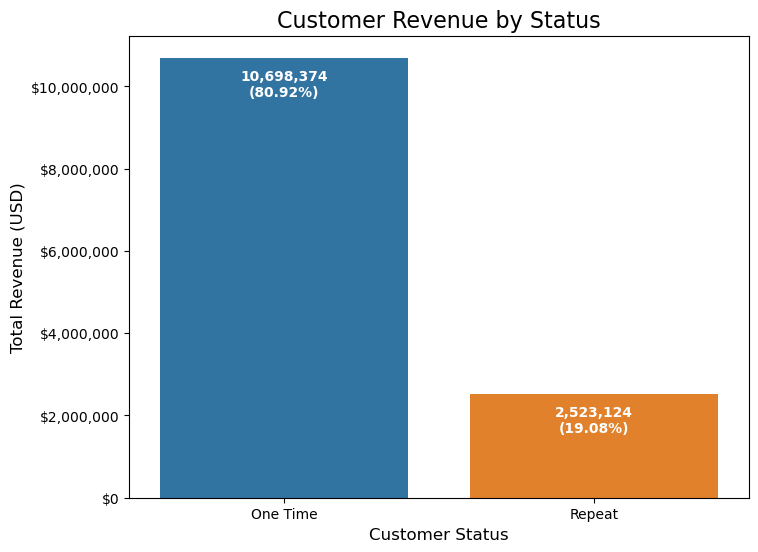

In [27]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.barplot(
    x="customer_status",
    y="total_revenue",
    data=customer_status_summary,
    ax=ax
)


# Add labels INSIDE the bar (top position)
for container in ax.containers:
    labels = [
        f'{rev:,.0f}\n({pct}%)'
        for rev, pct in zip(
            customer_status_summary["total_revenue"],
            customer_status_summary["revenue_percentage"]
        )
    ] 
    ax.bar_label(
        container,
        labels=labels,
        label_type='edge',   # positions at top edge of bar
        padding= -30,         # 🔥 pushes label inside the bar
        color='white',       # white text
        fontsize=10,
        fontweight='bold'
    )

# Format y-axis as currency
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))

# Titles and labels
ax.set_title("Customer Revenue by Status", fontsize=16)
ax.set_xlabel("Customer Status", fontsize=12)
ax.set_ylabel("Total Revenue (USD)", fontsize=12)

plt.show()

### Customer Revenue by Status

**Objective:**  
To analyze how revenue is distributed between one-time and repeat customers.

**Methodology:**  
- Grouped data by `customer_unique_id` to calculate total orders and revenue.
- Classified customers into:
  - One Time (1 order)
  - Repeat (more than 1 order)
- Aggregated revenue by customer status.
- Visualized using a bar chart with revenue and percentage labels.

**Key Insights:**  
- One-time customers contribute 80.92% of total revenue.
- Repeat customers contribute only 19.08%.
- Revenue is heavily dependent on new customers.

**Interpretation:**  
- The business has strong acquisition but weak retention.
- Most customers do not return after their first purchase.
- There is a significant opportunity to improve customer lifetime value.

**Visualization Notes:**  
- Labels inside bars show both revenue and percentage contribution.
- Y-axis is formatted in USD with thousands separator for readability.
- Color palette and layout are kept consistent for clarity.

In [28]:
customer_summary

,customer_unique_id,total_orders,total_revenue,customer_status
0,0000366f3b9a7992bf8c76cfdf3221e2,1,129.90,One Time
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,18.90,One Time
2,0000f46a3911fa3c0805444483337064,1,69.00,One Time
3,0000f6ccb0745a6a4b88665a16c9f078,1,25.99,One Time
4,0004aac84e0df4da2b147fca70cf8255,1,180.00,One Time
...,...,...,...,...
93353,fffcf5a5ff07b0908bd4e2dbc735a684,2,1570.00,Repeat
93354,fffea47cd6d3cc0a88bd621562a9d061,1,64.89,One Time
93355,ffff371b4d645b6ecea244b27531430a,1,89.90,One Time
93356,ffff5962728ec6157033ef9805bacc48,1,115.00,One Time


In [29]:
customer_status_summary

,customer_status,total_orders,total_revenue,revenue_percentage
0,One Time,81748,10698374.21,80.92
1,Repeat,28449,2523123.90,19.08


### Customer Order Summary (AOV)

In [30]:
customer_status_summary["avg_order_value"] = (
    customer_status_summary["total_revenue"] /
    customer_status_summary["total_orders"]
).round()
customer_status_summary

,customer_status,total_orders,total_revenue,revenue_percentage,avg_order_value
0,One Time,81748,10698374.21,80.92,131.0
1,Repeat,28449,2523123.90,19.08,89.0


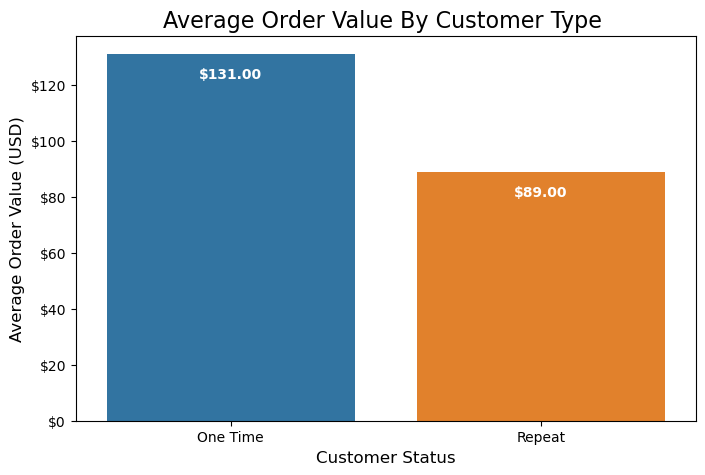

In [31]:
fig, ax = plt.subplots(figsize=(8,5))

sns.barplot(
    data=customer_status_summary,
    x="customer_status",
    y="avg_order_value",
    ax=ax
)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.2f}' for v in customer_status_summary["avg_order_value"]],
        padding=-20,
        color="white",
        fontweight="bold"
    )

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))

ax.set_title("Average Order Value By Customer Type ", fontsize=16)
ax.set_ylabel("Average Order Value (USD)", fontsize=12)
ax.set_xlabel("Customer Status", fontsize=12)

plt.show()

### Average Order Value (AOV) Analysis

**Objective:**  
To evaluate customer spending behavior by comparing average order value between one-time and repeat customers.

**Methodology:**  
- Calculated total orders and total revenue for each customer group.
- Computed Average Order Value (AOV) as:
  - AOV = Total Revenue / Total Orders
- Compared metrics across customer segments.

**Key Insights:**  
- One-time customers have a higher AOV ($131) than repeat customers ($89).
- One-time customers account for 80.92% of total revenue.
- Repeat customers contribute only 19.08% of revenue.

**Interpretation:**  
- Customers tend to make higher-value purchases initially but do not return frequently.
- Repeat customers generate lower revenue per transaction, indicating weaker engagement.
- This suggests a gap in customer retention and long-term value creation.

**Business Implications:**  
- The business relies heavily on new customer acquisition for revenue growth.
- Improving customer retention could significantly increase overall revenue.
- There is a need to enhance post-purchase engagement and customer experience.

**Visualization Notes:**  
- Bar chart compares AOV across customer types.
- Labels inside bars display formatted currency values.
- Consistent styling is applied for readability and comparison.

In [32]:
customer_status_summary.drop(columns=["average_order_value"], inplace=True)

KeyError: "['average_order_value'] not found in axis"

In [ ]:
merged_orders.info()

### Product by Revenue

In [33]:
# Group by product and calculate revenue + quantity
product_summary = (
    merged_orders
    .groupby("product_id")
    .agg(
        total_revenue=("price", "sum"),
        total_units_sold=("order_id", "count")
    )
    .reset_index()
)

# Sort by revenue
top_products_revenue = (
    product_summary
    .sort_values(by="total_revenue", ascending=False)
    .head(10)
)

top_products_revenue

,product_id,total_revenue,total_units_sold
23546,bb50f2e236e5eea0100680137654686c,63560.00,194
13749,6cdd53843498f92890544667809f1595,53652.30,153
26997,d6160fb7873f184099d9bc95e30376af,45949.35,33
26436,d1c427060a0f73f6b889a5c7c61f2ac4,45620.56,332
19290,99a4788cb24856965c36a24e339b6058,42049.66,477
7881,3dd2a17168ec895c781a9191c1e95ad7,40782.80,272
4892,25c38557cf793876c5abdd5931f922db,38907.32,38
12074,5f504b3a1c75b73d6151be81eb05bdc9,37733.90,63
10616,53b36df67ebb7c41585e8d54d6772e08,37454.63,321
21617,aca2eb7d00ea1a7b8ebd4e68314663af,37104.30,520


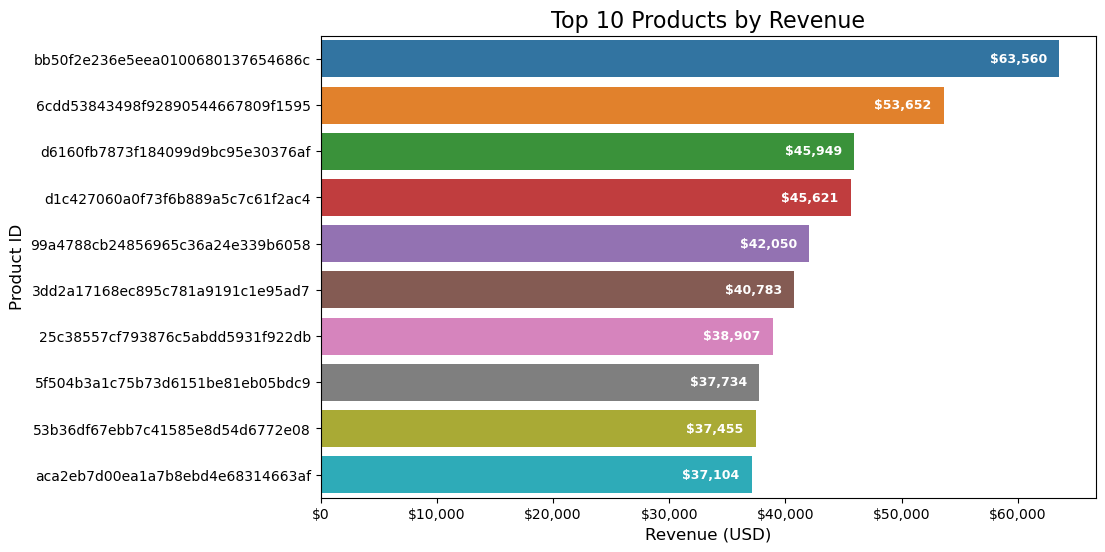

In [34]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    x="total_revenue",
    y="product_id",
    data=top_products_revenue,
    ax=ax
)

# Add labels inside bars
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.0f}' for v in top_products_revenue["total_revenue"]],
        padding=-50,
        color='white',
        fontsize=9,
        fontweight='bold'
    )

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))

# Titles
ax.set_title("Top 10 Products by Revenue", fontsize=16)
ax.set_xlabel("Revenue (USD)", fontsize=12)
ax.set_ylabel("Product ID", fontsize=12)

plt.show()

In [35]:
top_products_unit = (
    product_summary
    .sort_values(by="total_units_sold", ascending=False)
    .head(10)
)
top_products_unit

,product_id,total_revenue,total_units_sold
21617,aca2eb7d00ea1a7b8ebd4e68314663af,37104.30,520
8429,422879e10f46682990de24d770e7f83d,26577.22,484
19290,99a4788cb24856965c36a24e339b6058,42049.66,477
7206,389d119b48cf3043d311335e499d9c6b,21336.79,390
6926,368c6c730842d78016ad823897a372db,21056.80,388
10589,53759a2ecddad2bb87a079a1f1519f73,20387.20,373
26436,d1c427060a0f73f6b889a5c7c61f2ac4,45620.56,332
10616,53b36df67ebb7c41585e8d54d6772e08,37454.63,321
2734,154e7e31ebfa092203795c972e5804a6,6173.26,274
7881,3dd2a17168ec895c781a9191c1e95ad7,40782.80,272


NameError: name 'top_products_units' is not defined

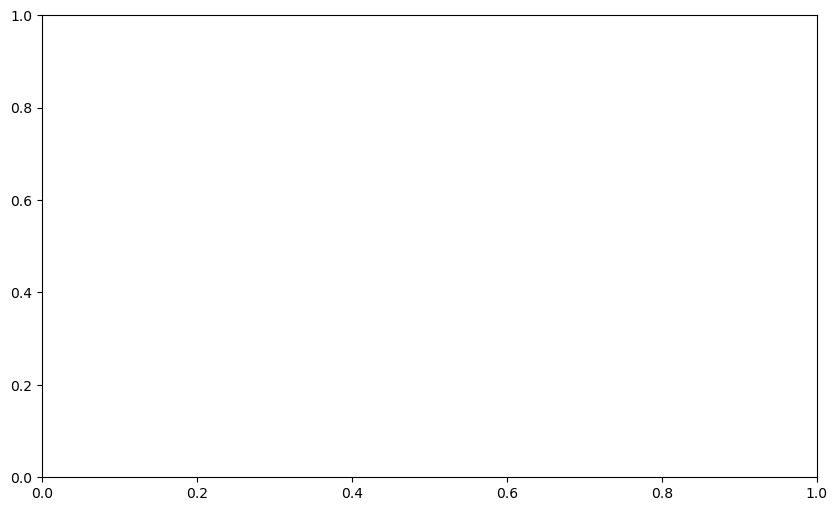

In [36]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    x="total_units_sold",
    y="product_id",
    data=top_products_units,
    ax=ax
)

# Add labels
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.0f}' for v in top_products_units["total_units_sold"]],
        label_type='edge',
        padding=-40,
        color='white',
        fontsize=9,
        fontweight='bold'
    )

# Titles
ax.set_title("Top 10 Products by Units Sold", fontsize=16)
ax.set_xlabel("Units Sold")
ax.set_ylabel("Product ID")

plt.show()

### Product Performance Analysis

**Objective:**  
To identify top-performing products based on revenue and sales volume, and understand their impact on customer behavior.

**Methodology:**  
- Aggregated data by product_id.
- Calculated:
  - Total Revenue (SUM of price)
  - Total Units Sold (COUNT of orders)
- Ranked top products by revenue and units sold.
- Compared overlapping products across both rankings.

**Key Insights:**  
- Several products appear in both top revenue and top sales lists, indicating strong overall performance.
- Some products generate high revenue with low sales volume, indicating high-priced items.
- Other products have high sales volume but lower revenue, indicating low-cost, frequently purchased items.

**Interpretation:**  
- High-revenue, low-volume products are likely one-time purchases.
- High-volume, low-revenue products are likely repeat purchase items.
- This explains why repeat customers have lower average order value.

**Business Implications:**  
- The business relies on expensive one-time purchases for revenue.
- Repeat purchases are driven by lower-value products.
- There is an opportunity to:
  - Bundle products
  - Recommend complementary items
  - Encourage repeat purchases of high-value products

**Visualization Notes:**  
- Horizontal bar charts improve readability for product IDs.
- Labels display formatted revenue and units sold.
- Consistent styling ensures clarity across analyses.

In [315]:
product_full = pd.merge(
    products,
    pcnt,
    on="product_category_name"
)

product_full = product_full.rename(columns={"product_category_name_english": "product_category"})
product_full["product_category"] = product_full["product_category"].str.strip().str.replace("_", " ").str.capitalize()
product_full = product_full.drop(columns=["product_category_name"])

product_full

,product_id,product_name_length,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category
0,00066f42aeeb9f3007548bb9d3f33c38,53.0,596.0,6,300.0,20.0,16.0,16.0,Perfumery
1,005030ef108f58b46b78116f754d8d38,54.0,942.0,1,50.0,16.0,5.0,11.0,Perfumery
2,009c09f439988bc06a93d6b8186dce73,39.0,991.0,3,150.0,20.0,20.0,20.0,Perfumery
3,00baba5b58e274d0332a0c8a0a66f877,27.0,406.0,4,200.0,18.0,7.0,12.0,Perfumery
4,00c3e35b00dd00ab864d4a94c1b97e66,58.0,596.0,4,512.0,30.0,12.0,18.0,Perfumery
...,...,...,...,...,...,...,...,...,...
32323,ab0a97f604550b5b5b99180a6dc04461,34.0,150.0,1,150.0,60.0,11.0,11.0,Tablets printing image
32324,b29c1749f99da888ea322a01420d5220,60.0,2532.0,5,1100.0,30.0,5.0,22.0,Tablets printing image
32325,fa9d34c32a70b4e50a4c2c8c2c42051f,54.0,145.0,1,100.0,16.0,6.0,14.0,Tablets printing image
32326,6c7a0a349ad11817745e3ad58abd5c79,55.0,506.0,1,1225.0,27.0,35.0,15.0,Security and services


In [317]:
high_revenue_high_demand = pd.merge(
    top_products_revenue[["product_id", "total_revenue", "total_units_sold"]],
    top_products_unit[["product_id"]],
    on="product_id"
)

high_revenue_high_demand = pd.merge(
    high_revenue_high_demand[["product_id", "total_revenue", "total_units_sold"]],
    product_full[["product_id", "product_category"]],
    on="product_id")


high_revenue_high_demand

,product_id,total_revenue,total_units_sold,product_category
0,d1c427060a0f73f6b889a5c7c61f2ac4,45620.56,332,Computers accessories
1,99a4788cb24856965c36a24e339b6058,42049.66,477,Bed bath table
2,3dd2a17168ec895c781a9191c1e95ad7,40782.80,272,Computers accessories
3,53b36df67ebb7c41585e8d54d6772e08,37454.63,321,Watches gifts
4,aca2eb7d00ea1a7b8ebd4e68314663af,37104.30,520,Furniture decor


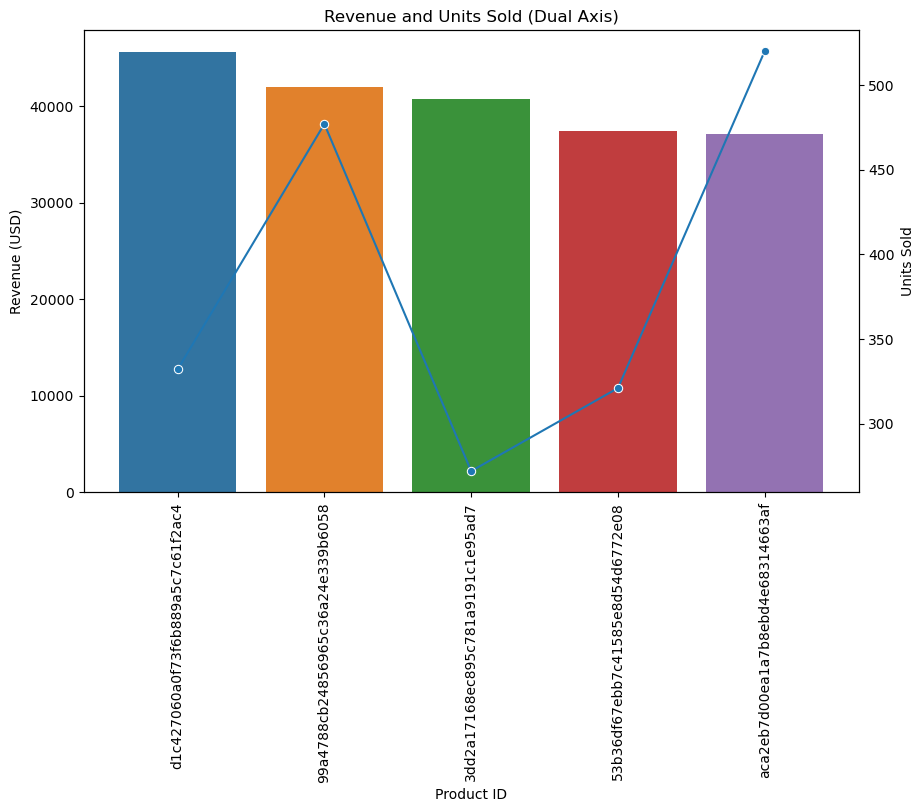

In [385]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# First axis (Revenue)
sns.barplot(
    x="product_id",
    y="total_revenue",
    data=high_revenue_high_demand,
    ax=ax1
)

ax1.set_ylabel("Revenue (USD)")
ax1.set_xlabel("Product ID")


# Second axis (Units Sold)
ax2 = ax1.twinx()

sns.lineplot(
    x="product_id",
    y="total_units_sold",
    data=high_revenue_high_demand,
    ax=ax2,
    marker="o"
)


ax2.set_ylabel("Units Sold")

# Rotate labels
ax1.tick_params(axis='x', rotation=90)

ax1.set_title("Revenue and Units Sold (Dual Axis)")

plt.show()

### Revenue vs Units Sold Visualization

**Objective:**  
To compare product performance (revenue) and demand (units sold) in a single view.

**Methodology:**  
- Used dual-axis visualization:
  - Bar chart for total revenue
  - Line chart for units sold
- Created a secondary axis using `twinx()` to handle different scales.

**Key Insights:**  
- Products with high revenue and high units sold are top performers.
- Products with high revenue but low units are expensive items.
- Products with high units but lower revenue are frequently purchased low-cost items.

**Interpretation:**  
- Dual-axis visualization allows comparison of two different metrics without distortion.
- Helps identify product positioning (premium vs volume-driven).

**Visualization Notes:**  
- Bars represent revenue (left axis).
- Line represents units sold (right axis).
- Rotation applied for readability of product IDs.

### High Revenue & High Demand Products

**Objective:**  
Identify products that generate high revenue *and* have high customer demand.

**Methodology:**  
- Merged `products` table with `product category` table to get English category names.
- Filtered top products by revenue (`top_products_revenue`).
- Further filtered to include only products that also have high sales volume (`top_products_units`).

**Key Insights:**  
- These products are the most valuable to the business because they:
  - Generate high revenue
  - Are frequently purchased
- They often appear in both top revenue and top units sold lists.

**Business Implications:**  
- Prioritize stock management for these products.
- Feature them in marketing campaigns.
- Consider bundling or upselling with complementary items.

**SQL Equivalent:**  

```sql
SELECT r.product_id, r.total_revenue, f.product_category_name_english, u.total_units_sold
FROM top_products_revenue r
JOIN product_full f
    ON r.product_id = f.product_id
JOIN top_products_units u
    ON r.product_id = u.product_id
ORDER BY r.total_revenue DESC, u.total_units_sold DESC;

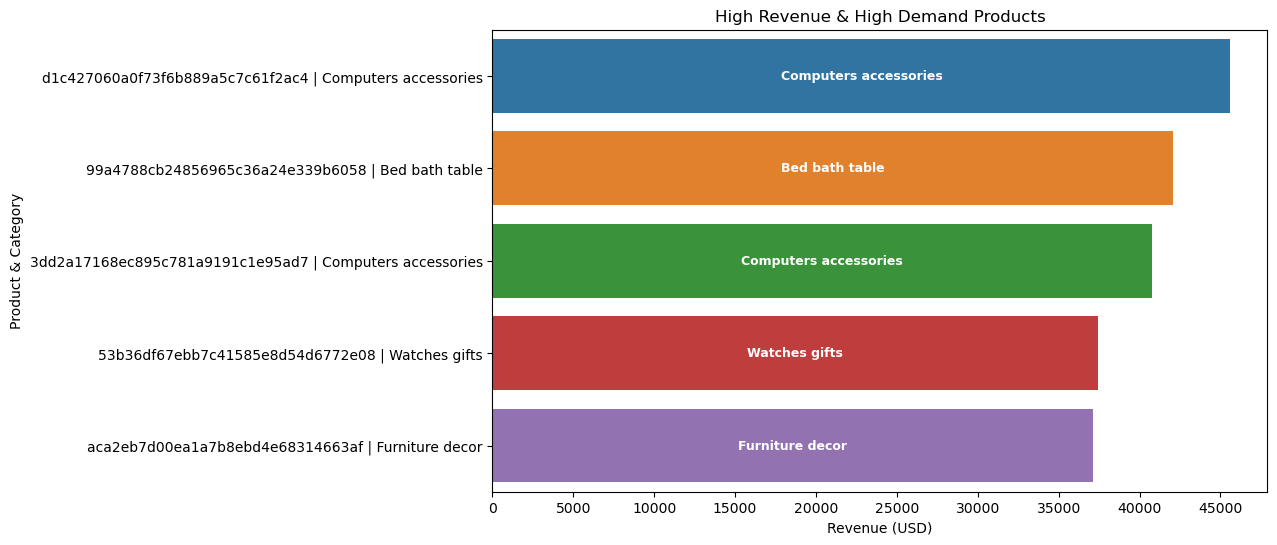

In [392]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    x="total_revenue",
    y="product_label",
    data=high_revenue_high_demand,
    ax=ax
)

# Add numeric labels
for container in ax.containers:
    ax.bar_label(
        container,
        labels=high_revenue_high_demand["product_category"],
        label_type='center',
        color='white',
        fontsize=9,
        fontweight='bold'
    )

ax.xaxis.set_major_locator(MultipleLocator(5000))

ax.set_title("High Revenue & High Demand Products")
ax.set_xlabel("Revenue (USD)")
ax.set_ylabel("Product & Category")

plt.show()

### PRODUCT SEGMENTATION (Quadrant Analysis)